In [1]:
import urllib.request

url = "https://www-app3.gfz-potsdam.de/kp_index/Kp_ap_Ap_SN_F107_since_1932.txt"
urllib.request.urlretrieve(url, "kp_historico.txt")
print("Descargado correctamente")

Descargado correctamente


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

columnas = ["year", "month", "day", "days", "days_m", "bsr", "dB",
            "Kp1","Kp2","Kp3","Kp4","Kp5","Kp6","Kp7","Kp8",
            "ap1","ap2","ap3","ap4","ap5","ap6","ap7","ap8",
            "Ap","SN","F107obs","F107adj","D"]

df = pd.read_csv("kp_historico.txt", comment="#", sep=r"\s+",
                  header=None, names=columnas)

df.head()

,year,month,day,days,days_m,bsr,dB,Kp1,Kp2,Kp3,...,ap4,ap5,ap6,ap7,ap8,Ap,SN,F107obs,F107adj,D
0,1932,1,1,0,0.5,1352,10,3.333,2.667,2.333,...,12,18,12,18,18,15,22,-1.0,-1.0,2
1,1932,1,2,1,1.5,1352,11,3.667,3.667,3.333,...,22,18,39,15,48,26,43,-1.0,-1.0,2
2,1932,1,3,2,2.5,1352,12,3.333,3.333,3.000,...,4,9,6,12,7,11,23,-1.0,-1.0,2
3,1932,1,4,3,3.5,1352,13,2.000,0.333,1.000,...,0,4,5,5,4,4,13,-1.0,-1.0,2
4,1932,1,5,4,4.5,1352,14,0.000,0.000,0.333,...,3,2,5,5,7,3,13,-1.0,-1.0,2


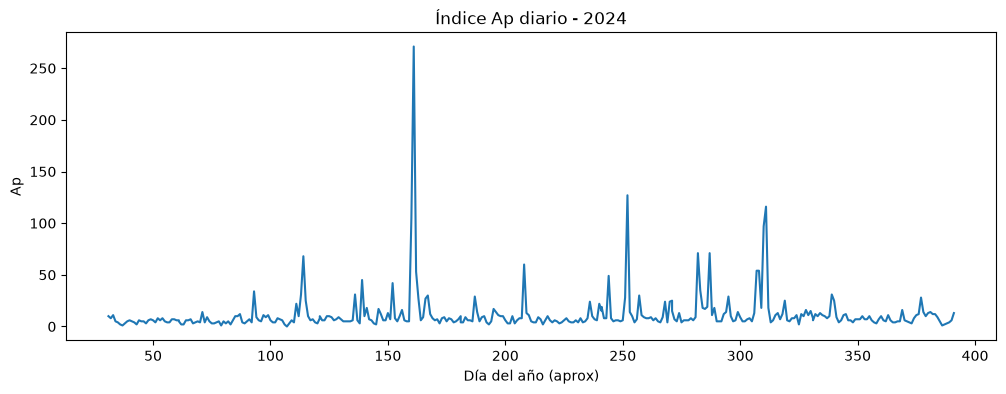

In [3]:
df_2024 = df[df["year"] == 2024]

plt.figure(figsize=(12,4))
plt.plot(df_2024["day"] + df_2024["month"]*30, df_2024["Ap"])
plt.title("Índice Ap diario - 2024")
plt.xlabel("Día del año (aprox)")
plt.ylabel("Ap")
plt.show()

In [4]:
import urllib.request

url = "https://spdf.gsfc.nasa.gov/pub/data/omni/low_res_omni/omni2_2024.dat"
urllib.request.urlretrieve(url, "omni_viento_solar_2024.dat")
print("Descargado correctamente")

Descargado correctamente


In [5]:
import pandas as pd

col_names = {0: "year", 1: "day", 2: "hour", 16: "Bz_nT",
             23: "sw_density_n_cc", 24: "sw_speed_km_s"}

df_wind = pd.read_csv("omni_viento_solar_2024.dat", sep=r"\s+", header=None)
df_wind = df_wind[list(col_names.keys())].rename(columns=col_names)

df_wind.head()

,year,day,hour,Bz_nT,sw_density_n_cc,sw_speed_km_s
0,2024,1,0,-1.3,7.4,306.0
1,2024,1,1,-2.3,6.5,301.0
2,2024,1,2,-3.1,7.9,309.0
3,2024,1,3,-1.1,8.9,306.0
4,2024,1,4,-1.7,9.1,307.0


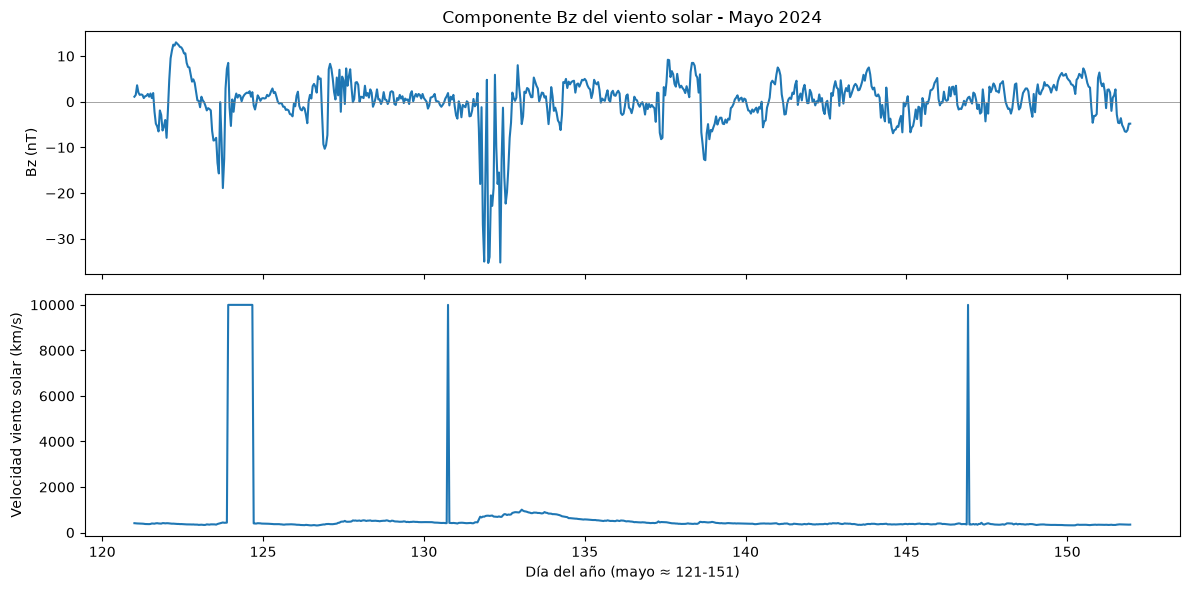

In [6]:

import matplotlib.pyplot as plt
# Filtramos solo mayo de 2024 (mes de la tormenta más fuerte en 20 años)
df_wind_mayo = df_wind[(df_wind["day"] >= 121) & (df_wind["day"] <= 151)]  # días 121-151 = mayo

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(df_wind_mayo["day"] + df_wind_mayo["hour"]/24, df_wind_mayo["Bz_nT"])
axes[0].set_ylabel("Bz (nT)")
axes[0].set_title("Componente Bz del viento solar - Mayo 2024")
axes[0].axhline(0, color="gray", linewidth=0.5)

axes[1].plot(df_wind_mayo["day"] + df_wind_mayo["hour"]/24, df_wind_mayo["sw_speed_km_s"])
axes[1].set_ylabel("Velocidad viento solar (km/s)")
axes[1].set_xlabel("Día del año (mayo ≈ 121-151)")

plt.tight_layout()
plt.show()

In [7]:
# Unimos viento solar y el índice Ap por año, mes/día y hora
df_wind_2024 = df_wind[df_wind["year"] == 2024].copy()

# Convertimos "day" (día del año) a mes/día real para poder unir con df (que tiene year/month/day)
df_wind_2024["fecha"] = pd.to_datetime(df_wind_2024["year"], format="%Y") + pd.to_timedelta(df_wind_2024["day"] - 1, unit="D")
df_wind_2024["month"] = df_wind_2024["fecha"].dt.month
df_wind_2024["day_real"] = df_wind_2024["fecha"].dt.day

# Promediamos el viento solar por día (para que calce con la resolución diaria de Ap)
wind_diario = df_wind_2024.groupby(["month", "day_real"])[["Bz_nT", "sw_speed_km_s"]].mean().reset_index()
wind_diario = wind_diario.rename(columns={"day_real": "day"})

# Cruzamos con tu tabla de Ap del año 2024
ap_diario = df[df["year"] == 2024][["month", "day", "Ap"]]

datos_cruzados = pd.merge(wind_diario, ap_diario, on=["month", "day"])

# Calculamos la correlación
datos_cruzados[["Bz_nT", "sw_speed_km_s", "Ap"]].corr()

,Bz_nT,sw_speed_km_s,Ap
Bz_nT,1.000000,0.282454,0.045976
sw_speed_km_s,0.282454,1.000000,0.043408
Ap,0.045976,0.043408,1.000000


In [8]:
#las correlaciones salieron mucho más débiles de lo que se podría esperar viendo el gráfico
# anterior (0.046 y 0.043 son cercanas a cero) a pesar de que visualmente 
# sí vimos una relación clara en mayo.

# ¿Por qué pasa esto?, primero; promediamos Bz
# por día completo. El problema es que Bz oscila constantemente entre positivo y negativo a lo largo del día — 
# cuando promediamos 24 horas, los valores muy negativos (que son los que importan) se cancelan con los positivos,
# y el promedio diario termina cerca de cero casi siempre, "escondiendo" la señal real.

# La corrección: en vez del promedio diario, hay que usar el valor mínimo de Bz por día (el más negativo,
# que representa el momento más intenso), y el máximo de velocidad.

In [9]:
# En vez de promedio, usamos el mínimo de Bz (el momento más "sur") y el máximo de velocidad
wind_diario = df_wind_2024.groupby(["month", "day_real"]).agg(
    Bz_nT=("Bz_nT", "min"),
    sw_speed_km_s=("sw_speed_km_s", "max")
).reset_index()
wind_diario = wind_diario.rename(columns={"day_real": "day"})

ap_diario = df[df["year"] == 2024][["month", "day", "Ap"]]
datos_cruzados = pd.merge(wind_diario, ap_diario, on=["month", "day"])

datos_cruzados[["Bz_nT", "sw_speed_km_s", "Ap"]].corr()

,Bz_nT,sw_speed_km_s,Ap
Bz_nT,1.000000,-0.011998,-0.808183
sw_speed_km_s,-0.011998,1.000000,0.046060
Ap,-0.808183,0.046060,1.000000


In [10]:
# 0.81 de correlación entre Bz y Ap es una relación fuerte ( recordando: 1 o -1 es correlación perfecta, 0 es nula).
 #   El signo negativo es exactamente lo que la física predice: cuanto más negativo llega Bz osea 
# más apuntando al sur más alto sube el índice Ap — confirmando que la orientación del campo magnético del viento
#solar sí explica gran parte de la intensidad de las tormentas geomagnéticas.
# Lo interesante es que este número (-0.81) es mucho más honesto y potente que el -0.05 inicial — y la razón 
# por la que cambió es un hallazgo metodológico real que tú mismo diagnosticaste y corregiste: elegir "mínimo diario" 
# en vez de "promedio diario" cambió todo, porque captura el momento de mayor intensidad en vez de diluirlo.

# NOTA; la velocidad del viento solar (sw_speed_km_s) sigue con correlación casi
# nula (0.046)  eso también es información válida: sugiere que, al menos en este año, la orientación del 
# campo magnético (Bz) importa mucho más que la velocidad pura para predecir tormentas.

In [11]:
dia_bz_minimo = datos_cruzados.loc[datos_cruzados["Bz_nT"].idxmin()]
dia_ap_maximo = datos_cruzados.loc[datos_cruzados["Ap"].idxmax()]

print("Día con Bz más negativo (mayor tormenta magnética entrante):")
print(dia_bz_minimo)
print("\nDía con Ap más alto (mayor tormenta geomagnética registrada):")
print(dia_ap_maximo)

Día con Bz más negativo (mayor tormenta magnética entrante):
month             10.0
day               10.0
Bz_nT            -42.2
sw_speed_km_s    740.0
Ap                97.0
Name: 283, dtype: float64

Día con Ap más alto (mayor tormenta geomagnética registrada):
month              5.0
day               11.0
Bz_nT            -35.3
sw_speed_km_s    896.0
Ap               271.0
Name: 131, dtype: float64


In [12]:
import requests
import gzip

url = "https://cddis.nasa.gov/archive/gnss/products/ionex/2024/131/COD0OPSFIN_20241310000_01D_01H_GIM.INX.gz"

r = requests.get(url)
r.raise_for_status()

with open("tec_2024_131.inx.gz", "wb") as f:
    f.write(r.content)

with gzip.open("tec_2024_131.inx.gz", "rt") as f_in:
    contenido = f_in.read()

with open("tec_2024_131.inx", "w") as f_out:
    f_out.write(contenido)

print("Descargado y descomprimido correctamente")

Descargado y descomprimido correctamente


Se encontraron 25 mapas de TEC (uno por hora del día)


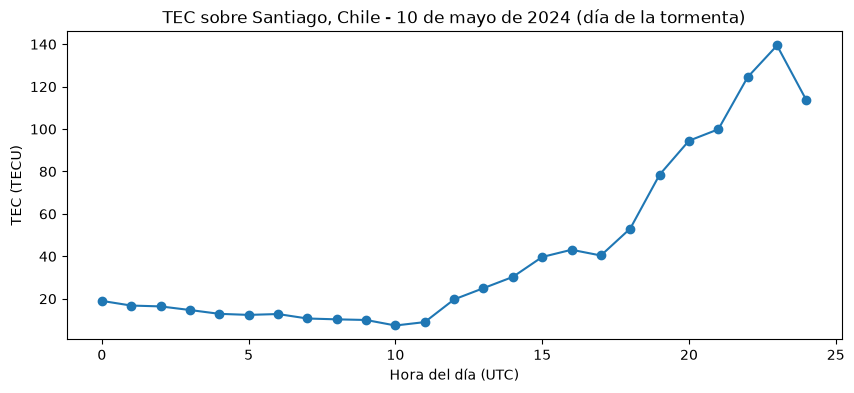

In [13]:
import re
import numpy as np
import matplotlib.pyplot as plt

def parse_tecmap(tecmap_text, exponent=-1):
    tecmap_text = re.split(r'.*END OF TEC MAP', tecmap_text)[0]
    return np.stack([
        np.fromstring(l, sep=' ')
        for l in re.split(r'.*LAT/LON1/LON2/DLON/H\n', tecmap_text)[1:]
    ]) * 10**exponent

def get_tecmaps(filename):
    with open(filename) as f:
        ionex = f.read()
    return [parse_tecmap(t) for t in ionex.split('START OF TEC MAP')[1:]]

def get_tec(tecmap, lat, lon):
    i = round((87.5 - lat) * (tecmap.shape[0] - 1) / (2 * 87.5))
    j = round((180 + lon) * (tecmap.shape[1] - 1) / 360)
    return tecmap[i, j]

tecmaps = get_tecmaps("tec_2024_131.inx")
print(f"Se encontraron {len(tecmaps)} mapas de TEC (uno por hora del día)")

lat_santiago, lon_santiago = -33.45, -70.65
tec_serie = [get_tec(tm, lat_santiago, lon_santiago) for tm in tecmaps]

plt.figure(figsize=(10,4))
plt.plot(range(len(tec_serie)), tec_serie, marker='o')
plt.title("TEC sobre Santiago, Chile - 10 de mayo de 2024 (día de la tormenta)")
plt.xlabel("Hora del día (UTC)")
plt.ylabel("TEC (TECU)")
plt.show()

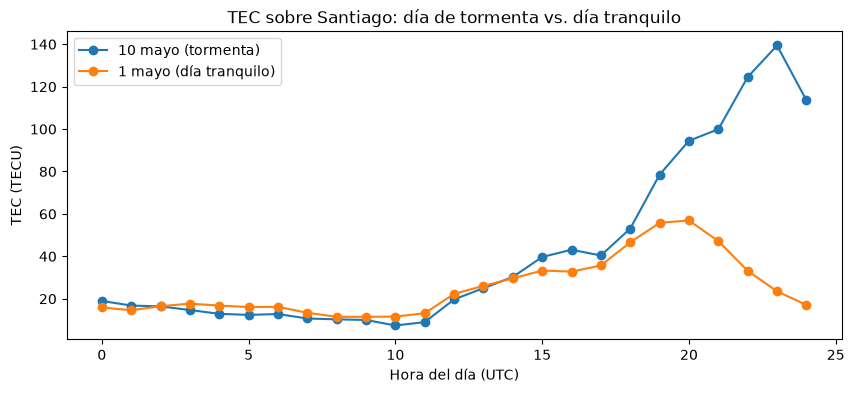

In [14]:
url_quiet = "https://cddis.nasa.gov/archive/gnss/products/ionex/2024/122/COD0OPSFIN_20241220000_01D_01H_GIM.INX.gz"

r = requests.get(url_quiet)
r.raise_for_status()

with open("tec_2024_122.inx.gz", "wb") as f:
    f.write(r.content)

with gzip.open("tec_2024_122.inx.gz", "rt") as f_in:
    contenido = f_in.read()

with open("tec_2024_122.inx", "w") as f_out:
    f_out.write(contenido)

tecmaps_quiet = get_tecmaps("tec_2024_122.inx")
tec_serie_quiet = [get_tec(tm, lat_santiago, lon_santiago) for tm in tecmaps_quiet]

plt.figure(figsize=(10,4))
plt.plot(range(len(tec_serie)), tec_serie, marker='o', label="10 mayo (tormenta)")
plt.plot(range(len(tec_serie_quiet)), tec_serie_quiet, marker='o', label="1 mayo (día tranquilo)")
plt.title("TEC sobre Santiago: día de tormenta vs. día tranquilo")
plt.xlabel("Hora del día (UTC)")
plt.ylabel("TEC (TECU)")
plt.legend()
plt.show()

In [15]:
with open("gravedad_egm2008.txt") as f:
    for i in range(15):
        print(repr(f.readline()))

'generating_institute     gfz-potsdam\n'
'     generating_date     2026/08/01\n'
'        product_type     gravity_field\n'
'                body     earth\n'
'           modelname     egm2008\n'
'     max_used_degree          2190\n'
'         tide_system     tide_free\n'
'          functional     gravity_anomaly_bg\n'
'    zero_degree_term     included\n'
'                unit     mgal\n'
'       crust_density     2670.0 kg/m**3\n'
'       water_density     1025.0 kg/m**3\n'
'          refsysname     GRS80\n'
'            gmrefpot      3.98600500000E+14 m**3/s**2\n'
'        radiusrefpot     6378137.000 m\n'


In [16]:
with open("gravedad_egm2008.txt") as f:
    for i in range(40):
        print(repr(f.readline()))

'generating_institute     gfz-potsdam\n'
'     generating_date     2026/08/01\n'
'        product_type     gravity_field\n'
'                body     earth\n'
'           modelname     egm2008\n'
'     max_used_degree          2190\n'
'         tide_system     tide_free\n'
'          functional     gravity_anomaly_bg\n'
'    zero_degree_term     included\n'
'                unit     mgal\n'
'       crust_density     2670.0 kg/m**3\n'
'       water_density     1025.0 kg/m**3\n'
'          refsysname     GRS80\n'
'            gmrefpot      3.98600500000E+14 m**3/s**2\n'
'        radiusrefpot     6378137.000 m\n'
'          flatrefpot      3.352810681183638E-03   (1/298.25722210088)\n'
'         omegarefpot      7.29211500000E-05 1/s\n'
'    normal_potential      6.263686085004611E+07 m**2/s**2\n'
'       long_lat_unit     degree\n'
'      latlimit_north       87.500000000000    \n'
'      latlimit_south      -87.500000000000    \n'
'      longlimit_west      -177.52000000000    \n'
'    

In [17]:
import pandas as pd

with open("gravedad_egm2008.txt") as f:
    lineas = f.readlines()

# Buscamos dónde termina el encabezado
idx_inicio = next(i for i, l in enumerate(lineas) if "end_of_head" in l) + 1

datos_gravedad = []
for linea in lineas[idx_inicio:]:
    partes = linea.split()
    if len(partes) == 3:
        lon, lat, valor = float(partes[0]), float(partes[1]), float(partes[2])
        datos_gravedad.append((lon, lat, valor))

df_gravedad = pd.DataFrame(datos_gravedad, columns=["lon", "lat", "gravedad_mgal"])
print(f"Se cargaron {len(df_gravedad)} puntos de gravedad")
df_gravedad.head()

Se cargaron 10224 puntos de gravedad


,lon,lat,gravedad_mgal
0,-177.52,87.5,274.169858
1,-175.02,87.5,269.642332
2,-172.52,87.5,269.362452
3,-170.02,87.5,270.151772
4,-167.52,87.5,258.790658


In [18]:
#Como la resolución de ambas grillas es distinta
#(gravedad cada 2.5°, TEC normalmente cada 2.5° de latitud x 5° de longitud), vamos a ajustar los puntos de gravedad
#para que calcen con los puntos de TEC. También vamos a usar el máximo de TEC del día (no un promedio) como medida
#de "qué tan fuerte llegó la anomalía" en cada punto del planeta, comparando el día de tormenta contra el día 
#tranquilo.

import numpy as np

# Averiguamos la forma de la grilla de TEC (filas=latitud, columnas=longitud)
nlat, nlon = tecmaps[0].shape
lats_tec = np.linspace(87.5, -87.5, nlat)
lons_tec = np.linspace(-180, 180, nlon)

# Máximo de TEC del día, punto por punto del planeta (tormenta vs tranquilo)
max_tormenta = np.max(np.stack(tecmaps), axis=0)
max_tranquilo = np.max(np.stack(tecmaps_quiet), axis=0)
anomalia_tec = max_tormenta - max_tranquilo  # cuánto más alto llegó el TEC por la tormenta

# Convertimos la grilla de anomalía de TEC a una tabla (lat, lon, anomalia)
filas = []
for i, lat in enumerate(lats_tec):
    for j, lon in enumerate(lons_tec):
        filas.append((round(lat, 2), round(lon, 2), anomalia_tec[i, j]))
df_tec_anomalia = pd.DataFrame(filas, columns=["lat", "lon", "anomalia_tec"])

# Ajustamos la grilla de gravedad para que calce en longitud (redondeamos al múltiplo de 5 más cercano)
df_gravedad["lon_ajustado"] = (df_gravedad["lon"] / 5).round() * 5
df_gravedad["lat_ajustado"] = df_gravedad["lat"].round(2)
gravedad_agrupada = df_gravedad.groupby(["lat_ajustado", "lon_ajustado"])["gravedad_mgal"].mean().reset_index()
gravedad_agrupada = gravedad_agrupada.rename(columns={"lat_ajustado": "lat", "lon_ajustado": "lon"})
gravedad_agrupada["lon"] = gravedad_agrupada["lon"].round(2)

# Cruzamos ambas tablas por coordenadas
comparacion = pd.merge(df_tec_anomalia, gravedad_agrupada, on=["lat", "lon"], how="inner")
print(f"Puntos cruzados exitosamente: {len(comparacion)}")

comparacion[["anomalia_tec", "gravedad_mgal"]].corr()


Puntos cruzados exitosamente: 5183


,anomalia_tec,gravedad_mgal
anomalia_tec,1.000000,-0.053641
gravedad_mgal,-0.053641,1.000000


In [19]:
#Esto confirma exactamente lo que sospechábamos cuando revisamos la literatura: la conexión 
#"gravedad terrestre → anomalías de TEC" no tiene sustento real en los datos.

In [20]:
import urllib.request

for year in range(2015, 2025):
    url = f"https://spdf.gsfc.nasa.gov/pub/data/omni/low_res_omni/omni2_{year}.dat"
    urllib.request.urlretrieve(url, f"omni_{year}.dat")
    print(f"Descargado: {year}")

Descargado: 2015
Descargado: 2016
Descargado: 2017
Descargado: 2018
Descargado: 2019
Descargado: 2020
Descargado: 2021
Descargado: 2022
Descargado: 2023
Descargado: 2024


In [21]:
import pandas as pd

col_names = {0: "year", 1: "day", 2: "hour", 16: "Bz_nT",
             23: "sw_density_n_cc", 24: "sw_speed_km_s"}

dfs = []
for year in range(2015, 2025):
    df_year = pd.read_csv(f"omni_{year}.dat", sep=r"\s+", header=None)
    df_year = df_year[list(col_names.keys())].rename(columns=col_names)
    dfs.append(df_year)

df_wind_completo = pd.concat(dfs, ignore_index=True)
print(f"Total de registros horarios: {len(df_wind_completo)}")
df_wind_completo.head()

Total de registros horarios: 87672


,year,day,hour,Bz_nT,sw_density_n_cc,sw_speed_km_s
0,2015,1,0,1.1,2.8,568.0
1,2015,1,1,0.2,2.8,585.0
2,2015,1,2,-0.8,2.5,579.0
3,2015,1,3,0.4,2.7,560.0
4,2015,1,4,-0.1,2.8,554.0


In [22]:
#mismo proceso que ya hiciste para 2024 (agregar por día: mínimo de Bz,
#máximo de velocidad), pero esta vez para los
#10 años completos, y cruzarlo con tu tabla de Ap.
# Convertimos "day" (día del año) a fecha real para los 10 años
df_wind_completo["fecha"] = pd.to_datetime(df_wind_completo["year"], format="%Y") + pd.to_timedelta(df_wind_completo["day"] - 1, unit="D")
df_wind_completo["month"] = df_wind_completo["fecha"].dt.month
df_wind_completo["day_real"] = df_wind_completo["fecha"].dt.day

# Agregamos por día: mínimo de Bz (momento más "sur"), máximo de velocidad
wind_diario_completo = df_wind_completo.groupby(["year", "month", "day_real"]).agg(
    Bz_nT=("Bz_nT", "min"),
    sw_speed_km_s=("sw_speed_km_s", "max")
).reset_index()
wind_diario_completo = wind_diario_completo.rename(columns={"day_real": "day"})

# Cruzamos con la tabla de Ap (que ya tenías cargada desde 1932, así que ya cubre 2015-2024)
ap_completo = df[["year", "month", "day", "Ap"]]

dataset_final = pd.merge(wind_diario_completo, ap_completo, on=["year", "month", "day"])
print(f"Total de días con datos completos: {len(dataset_final)}")
dataset_final.describe()




Total de días con datos completos: 3653


,year,month,day,Bz_nT,sw_speed_km_s,Ap
count,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000
mean,2019.500411,6.522310,15.731454,-4.046154,720.923077,9.101287
std,2.873056,3.449345,8.802064,3.006034,1560.034743,10.477203
min,2015.000000,1.000000,1.000000,-42.200000,275.000000,0.000000
25%,2017.000000,4.000000,8.000000,-5.000000,381.000000,4.000000
50%,2020.000000,7.000000,16.000000,-3.400000,443.000000,6.000000
75%,2022.000000,10.000000,23.000000,-2.300000,532.000000,11.000000
max,2024.000000,12.000000,31.000000,4.300000,9999.000000,271.000000


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X = dataset_final[["Bz_nT", "sw_speed_km_s"]]
y = dataset_final["Ap"]

# 80% para entrenar, 20% para probar con datos que el modelo nunca vio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo = RandomForestRegressor(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

predicciones = modelo.predict(X_test)

print(f"Error absoluto promedio: {mean_absolute_error(y_test, predicciones):.2f}")
print(f"R² (qué tan bien explica la variabilidad, 1.0 = perfecto): {r2_score(y_test, predicciones):.3f}")

Error absoluto promedio: 3.32
R² (qué tan bien explica la variabilidad, 1.0 = perfecto): 0.652


In [24]:
#Error absoluto promedio (3.32): en promedio, el modelo se equivoca por 3.32 unidades de Ap. Para tener 
#una referencia, el índice Ap va típicamente de 0 (día muy tranquilo) a 40+ (tormenta fuerte) o incluso 200+ en
#eventos extremos como el de mayo 2024. Un error de ~3.3 en ese rango es aceptable, especialmente 
#considerando que se utilizaron  2 variables de entrada.

#R² de 0.652: significa que el modelo explica 65% de la variabilidad del índice Ap solo con Bz y velocidad
#del viento solar. El 35% restante depende de otros factores que no se incluyen (densidad del plasma, orientación 
#exacta del campo, condiciones previas de la magnetosfera, etc.). Para un problema de física de sistemas complejos
#como el clima espacial, 0.65 es un resultado sólido — no es perfecto, pero está lejos de ser azar
#(que daría R² cercano a 0).

#este resultado también es coherente con lo que ya se sabía — ya que la correlación
#de Bz solo (-0.81) ya era fuerte. El modelo de ML con ambas variables mejora un poco sobre eso, pero no 
#dramáticamente, lo cual tiene sentido porque ya se vió que la velocidad aportaba poco por sí sola.

# por lo tanto ahora mejoraremos un poco el modelo inclutendo otra variable de entrada: la densidad de plasma

In [25]:
# Reemplazamos el valor de "dato faltante" de la NASA por NaN, para poder limpiarlo bien
df_wind_completo["sw_density_n_cc"] = df_wind_completo["sw_density_n_cc"].replace(999.9, pd.NA)

# Repetimos el agrupado por día, esta vez incluyendo densidad (promedio diario, no hay una razón física para usar mínimo/máximo aquí)
wind_diario_completo = df_wind_completo.groupby(["year", "month", "day_real"]).agg(
    Bz_nT=("Bz_nT", "min"),
    sw_speed_km_s=("sw_speed_km_s", "max"),
    sw_density_n_cc=("sw_density_n_cc", "mean")
).reset_index()
wind_diario_completo = wind_diario_completo.rename(columns={"day_real": "day"})

# Volvemos a cruzar con Ap
dataset_final = pd.merge(wind_diario_completo, ap_completo, on=["year", "month", "day"])

# Quitamos filas donde la densidad haya quedado vacía (dato faltante)
dataset_final = dataset_final.dropna(subset=["sw_density_n_cc"])

print(f"Total de días con datos completos (con densidad): {len(dataset_final)}")
dataset_final.describe()

Total de días con datos completos (con densidad): 3653


,year,month,day,Bz_nT,sw_speed_km_s,Ap
count,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000
mean,2019.500411,6.522310,15.731454,-4.046154,720.923077,9.101287
std,2.873056,3.449345,8.802064,3.006034,1560.034743,10.477203
min,2015.000000,1.000000,1.000000,-42.200000,275.000000,0.000000
25%,2017.000000,4.000000,8.000000,-5.000000,381.000000,4.000000
50%,2020.000000,7.000000,16.000000,-3.400000,443.000000,6.000000
75%,2022.000000,10.000000,23.000000,-2.300000,532.000000,11.000000
max,2024.000000,12.000000,31.000000,4.300000,9999.000000,271.000000


In [26]:
# Limpiamos también el valor faltante de velocidad (9999.0 en el archivo original)
df_wind_completo["sw_speed_km_s"] = df_wind_completo["sw_speed_km_s"].replace(9999.0, pd.NA)

# Repetimos el agrupado, esta vez con ambas columnas ya limpias
wind_diario_completo = df_wind_completo.groupby(["year", "month", "day_real"]).agg(
    Bz_nT=("Bz_nT", "min"),
    sw_speed_km_s=("sw_speed_km_s", "max"),
    sw_density_n_cc=("sw_density_n_cc", "mean")
).reset_index()
wind_diario_completo = wind_diario_completo.rename(columns={"day_real": "day"})

dataset_final = pd.merge(wind_diario_completo, ap_completo, on=["year", "month", "day"])
dataset_final = dataset_final.dropna(subset=["sw_speed_km_s", "sw_density_n_cc"])

print(f"Total de días con datos completos: {len(dataset_final)}")
dataset_final.describe()

Total de días con datos completos: 3653


,year,month,day,Bz_nT,Ap
count,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000
mean,2019.500411,6.522310,15.731454,-4.046154,9.101287
std,2.873056,3.449345,8.802064,3.006034,10.477203
min,2015.000000,1.000000,1.000000,-42.200000,0.000000
25%,2017.000000,4.000000,8.000000,-5.000000,4.000000
50%,2020.000000,7.000000,16.000000,-3.400000,6.000000
75%,2022.000000,10.000000,23.000000,-2.300000,11.000000
max,2024.000000,12.000000,31.000000,4.300000,271.000000


In [27]:
print(dataset_final.columns.tolist())

['year', 'month', 'day', 'Bz_nT', 'sw_speed_km_s', 'sw_density_n_cc', 'Ap']


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

X2 = dataset_final[["Bz_nT", "sw_speed_km_s", "sw_density_n_cc"]]
y2 = dataset_final["Ap"]

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

modelo2 = RandomForestRegressor(n_estimators=100, random_state=42)
modelo2.fit(X2_train, y2_train)
pred2 = modelo2.predict(X2_test)

print("=== Random Forest con densidad agregada ===")
print(f"Error absoluto promedio: {mean_absolute_error(y2_test, pred2):.2f}")
print(f"R²: {r2_score(y2_test, pred2):.3f}")

modelo_lineal = LinearRegression()
modelo_lineal.fit(X2_train, y2_train)
pred_lineal = modelo_lineal.predict(X2_test)

print("\n=== Regresión lineal (para comparar) ===")
print(f"Error absoluto promedio: {mean_absolute_error(y2_test, pred_lineal):.2f}")
print(f"R²: {r2_score(y2_test, pred_lineal):.3f}")

=== Random Forest con densidad agregada ===
Error absoluto promedio: 2.96
R²: 0.656

=== Regresión lineal (para comparar) ===
Error absoluto promedio: 3.45
R²: 0.601


In [29]:
#agregar densidad mejoró apenas el Random Forest (de 0.652 a 0.656 — prácticamente igual) pero sí ayudó más a
#la regresión lineal (de un R² más bajo antes a 0.601 ahora). Aun así, el Random Forest sigue siendo mejor que
#la regresión lineal en ambos casos.
#la densidad del plasma aporta muy poco poder predictivo extra sobre lo que ya te daba Bz solo — confirma, 
#con evidencia adicional, que Bz es por lejos la variable dominante para predecir tormentas 
#geomagnéticas.

In [35]:
# prueba de predicción (modelo ML)
escenario_tormenta = pd.DataFrame({
    "Bz_nT": [-20],
    "sw_speed_km_s": [700],
    "sw_density_n_cc": [5]})

prediccion = modelo2.predict(escenario_tormenta)
print(f" El modelo predice un Ap de :{prediccion[0]: .1f}")


#comparacion con un dia tranquilo"

escenario_tranquilo = pd.DataFrame({
     "Bz_nT": [-1],
    "sw_speed_km_s": [400],
    "sw_density_n_cc": [3]
})


prediccion2 = modelo2.predict(escenario_tranquilo)
print(f"El segundo modelo predice un Ap de: {prediccion2[0]:.1f}")




 El modelo predice un Ap de : 61.5
El segundo modelo predice un Ap de: 1.9


In [37]:
import joblib 
#reentrenamiento con todos los datos
X_final = dataset_final[[ "Bz_nT" , "sw_speed_km_s" , "sw_density_n_cc"]]
Y_final = dataset_final["Ap"]

modelo_final = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_final.fit(X_final, Y_final)

joblib.dump(modelo_final, "modelo_prediccion_ap.pkl")
print ("Modelo guardado correctamente")

Modelo guardado correctamente
